In [149]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mpltern
import os
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel
from scipy.stats import norm
from warnings import simplefilter
from sklearn.exceptions import ConvergenceWarning
simplefilter("ignore", category=ConvergenceWarning)

# ---------------------------
# Helper Functions
# ---------------------------
def create_candidate_grid():
    """
    Create a uniform grid in the ternary space with compositions given in 1% steps.
    Only those combinations where A+B+C = 1 (i.e. 100%) are kept.
    """
    data = []
    # Loop over possible integer percentages for A and B. Then C = 100 - A - B.
    for a in range(101):
        for b in range(101 - a):
            c = 100 - a - b
            data.append([a/100, b/100, c/100])
    return pd.DataFrame(data, columns=["A", "B", "C"])

def compute_density(row, noise_std=0.5):
    """
    Compute synthetic density for a given alloy composition (row: A, B, C).
    Density model: density = 10*A + 15*B + 5*C + noise.
    """
    noise = np.random.normal(0, noise_std)
    density = 10 * row["A"] + 15 * row["B"] + 5 * row["C"] + noise
    return density

def label_from_density(density, threshold=12):
    """Return 1 if density > threshold, else 0."""
    return int(density > threshold)

# ---------------------------
# Settings and Initialization
# ---------------------------
np.random.seed(42)
density_threshold = 12  # threshold for classification

# Create candidate grid DataFrame
df_candidates = create_candidate_grid()
df_candidates.reset_index(inplace=True)  # preserve candidate index in a column named "index"

# For convenience, compute the ground truth density and binary label for each candidate.
# (This simulates the true measurement when a candidate is queried.)
df_candidates['Density'] = df_candidates.apply(compute_density, axis=1)
df_candidates['Label'] = df_candidates['Density'].apply(lambda d: label_from_density(d, density_threshold))

# Set aside an initial training set (queried candidates)
n_initial = 1
initial_idx = np.random.choice(df_candidates.index, n_initial, replace=False)
IDXs = [initial_idx[0]]

# Create training DataFrame; these are the points that have been "queried"
df_train = df_candidates.loc[initial_idx, ["index", "A", "B", "C", "Label",'Density']].copy().reset_index(drop=True)

# Create a pool DataFrame (candidates not yet queried)
df_pool = df_candidates.drop(initial_idx).reset_index(drop=True)

# Define Gaussian Process Model (we use regression on the binary label)
kernel = C(1.0) * RBF(length_scale=0.2)
gpr = GaussianProcessRegressor(kernel=kernel, random_state=42,normalize_y=True)

# Create output directory for iteration images
output_dir = "active_learning_iterations"
os.makedirs(output_dir, exist_ok=True)

In [150]:
# Number of active learning iterations
n_iterations = 3
Jaccard_Similarities = []

# ---------------------------
# Active Learning Loop
# ---------------------------
for it in range(n_iterations):
    # Fit the GP model on the current training data.
    X_train = df_train[["A", "B", "C"]].values
    y_train = df_train["Density"].values
    gpr.fit(X_train, y_train)
    
    # Predict on the full candidate grid (for visualization).
    X_candidates = df_candidates[["A", "B", "C"]].values
    y_pred, y_std = gpr.predict(X_candidates, return_std=True)
    print(y_pred)
    
    # Compute probability that density > density_threshold using the GP prediction distribution.
    # The probability is 1 - CDF((threshold - mean)/std). Note: when y_std is very small, the probability
    # will be nearly 0 or 1.
    prob_above_threshold = 1 - norm.cdf((density_threshold - y_pred) / y_std)

    ## To compare how fast each method found the solution (95% probability threshold)
    label_pred = (prob_above_threshold > 0.95).astype(int)
    jaccard_similarity = np.sum(np.logical_and(label_pred,df_candidates['Label'].values))/np.sum(np.logical_or(label_pred,df_candidates['Label'].values))
    Jaccard_Similarities.append(jaccard_similarity)
    # Select the next candidate from the remaining pool.
    ## Method 0 is randomly selecting among the pool.
    ## I found two methods using maximum entropy: 
    ## 1. Sample the point at maximum posterior variance. 
    ## 2. Expected Information Gain (Maximizing entropy reduction)
    method = 2
    if method == 0:
        next_idx = np.random.choice(df_pool.index) # Leave it as it was for the sake of comparison.
    elif method == 1:
        next_idx_df_candidates = np.argmax(y_std**2)
        next_idx = df_pool.loc[df_pool['index']==next_idx_df_candidates].index[0]
    elif method == 2:
        Entropy_Reductions = []
        for i in range(len(X_candidates)):
            y_pred_i, y_var_i = y_pred[i], y_std[i]**2
            prior_entropy = np.log(y_var_i + 1e-6)
            kernel2 = C(1.0) * RBF(length_scale=0.2)
            gprnew = GaussianProcessRegressor(kernel=kernel2, random_state=40,normalize_y=True)
            gprnew.fit(np.concatenate((X_train, X_candidates[i].reshape(1, -1))),np.append(y_train,y_pred_i+0.1*np.random.randn()))
            y_pred_i_new, y_var_i_new = gprnew.predict(X_candidates[i].reshape(1, -1), return_cov=True)
            post_entropy = np.log(y_var_i_new + 1e-6)[0][0]
            entropy_reduction = abs(post_entropy - prior_entropy)
            Entropy_Reductions.append(entropy_reduction)
        df_Entropy_Reductions = pd.DataFrame({'index':df_candidates['index'].values, 'entropy_reductions':Entropy_Reductions})
        indexes_Drop = df_Entropy_Reductions[df_Entropy_Reductions['index'].isin(IDXs)].index
        df_Entropy_Reductions.drop(indexes_Drop,inplace=True)
        max_index = df_Entropy_Reductions['entropy_reductions'].idxmax()
        next_idx_df_candidates = df_Entropy_Reductions.loc[max_index,'index']
        #print(IDXs)
        IDXs.append(next_idx_df_candidates)
        next_idx = df_pool.loc[df_pool['index']==next_idx_df_candidates].index[0]
    ##
    next_point = df_pool.loc[next_idx, ["index", "A", "B", "C", "Label",'Density']].copy()
    
    # Add the queried point to the training set.
    df_train = pd.concat([df_train, next_point.to_frame().T], ignore_index=True)
    
    # Remove the queried candidate from the pool.
    df_pool = df_pool.drop(next_idx).reset_index(drop=True)

[14.3631077 14.3631077 14.3631077 ... 14.3631077 14.3631077 14.3631077]
[ 8.46642554  8.38777144  8.31632038 ... 10.39371418 10.39371448
 10.39371404]
[ 8.49951728  8.41958862  8.34697971 ... 10.57708726 10.57560869
 10.57356866]


In [146]:
from sklearn_extra.cluster import KMedoids

In [ ]:
N = 5
r = 4

df_pool_array = df_pool.loc[:,['A','B','C']].values
kmedoids = KMedoids(n_clusters=N).fit(df_pool_array)
next_candidates_cluster_labels = kmedoids.labels_
df_pool_clusters = df_pool.copy()
df_pool_clusters['cluster'] = next_candidates_cluster_labels
Candidate_Batch_Indexes = []
Entropy_Reductions = []
for i in range(r):
    candidate_batch_indexes = []
    for j in range(N):
        df_pool_cluster_j = df_pool_clusters[df_pool_clusters['cluster']==j]
        candidate_batch_indexes.append(df_pool_cluster_j.sample(1).iat[0,0])
    candidate_batch = df_pool[df_pool['index'].isin(candidate_batch_indexes)]
    X_candidate_batch =  candidate_batch.loc[:,['A','B','C']].values
    y_sample_i = gpr.sample_y(X_candidate_batch,100)
    prior_entropy = np.sum(np.log(np.var(y_sample_i, axis=1)))
    kernel2 = C(1.0) * RBF(length_scale=0.2)
    gprnew = GaussianProcessRegressor(kernel=kernel2, random_state=40,normalize_y=True)
    gprnew.fit(np.concatenate((X_train, X_candidate_batch)),np.append(y_train,y_pred_i+0.1*np.random.randn(1,N)))
    y_sample_i_new = gprnew.sample_y(X_candidate_batch,100)
    post_entropy = np.sum(np.log(np.var(y_sample_i_new, axis=1)))
    entropy_reduction = abs(post_entropy - prior_entropy)

    Candidate_Batch_Indexes.append(candidate_batch_indexes)
    Entropy_Reductions.append(entropy_reduction)

entropy_reduction_i_max = np.argmax(Entropy_Reductions)
next_idx = Candidate_Batch_Indexes[entropy_reduction_i_max]


In [173]:
H = - prob_above_threshold*np.log(prob_above_threshold) - (1 - prob_above_threshold)*np.log(1 - prob_above_threshold)

/var/folders/t8/1dshmvf55gn478cb8nbc9x880000gn/T/ipykernel_19575/1876110181.py:1: RuntimeWarning: divide by zero encountered in log
  H = - prob_above_threshold*np.log(prob_above_threshold) - (1 - prob_above_threshold)*np.log(1 - prob_above_threshold)
/var/folders/t8/1dshmvf55gn478cb8nbc9x880000gn/T/ipykernel_19575/1876110181.py:1: RuntimeWarning: invalid value encountered in multiply
  H = - prob_above_threshold*np.log(prob_above_threshold) - (1 - prob_above_threshold)*np.log(1 - prob_above_threshold)


In [185]:
H = np.nan_to_num(H)

In [186]:
H[np.argpartition(H, -10)[-10:]]

array([0.69314626, 0.69314627, 0.69314711, 0.69314711, 0.69314627,
       0.69314628, 0.69314712, 0.69314713, 0.69314713, 0.69314713])

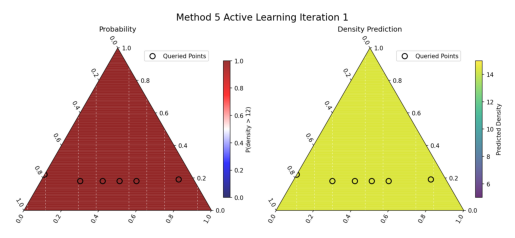

In [5]:
import os
import glob
from PIL import Image
import matplotlib.animation as animation
import matplotlib.pyplot as plt

# Get all PNG images in the current directory (or specify the path)
image_files = sorted(glob.glob("active_learning_iterations/iteration_*_method_5.png"))  # Adjust the path if needed

if not image_files:
    print("No PNG images found in the current directory.")
else:
    # Load images
    images = [Image.open(img) for img in image_files]

    # Create figure
    fig, ax = plt.subplots()
    ax.axis('off')  # Hide axes
    img_display = ax.imshow(images[0])  # Show first image

    # Update function for animation
    def update(frame):
        img_display.set_array(images[frame])
        return img_display,

    # Create animation
    ani = animation.FuncAnimation(fig, update, frames=len(images), interval=500, blit=True)

    # Display animation
    plt.show()
    ani.save("animation.gif", writer="pillow", fps=1)